In [18]:
from matplotlib.pylab import f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lightgbm import LGBMClassifier, log_evaluation, early_stopping
from collections import Counter


In [19]:
# 1. SETUP - Paste the 'to_drop' list from File 1 here
cols_to_drop =['ICMP', 'IPv', 'LLC', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'DNS', 'Drate', 'cwr_flag_number', 'ece_flag_number', 'ARP', 'DHCP', 'SMTP', 'Telnet', 'SSH', 'IRC']

dict_8classes = {
    'DDoS-VSE': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-TCP_Flood': 'DDoS', 
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon', 'SqlInjection': 'Web', 'BrowserHijacking': 'Web', 'CommandInjection': 'Web',
    'Backdoor_Detection': 'Web', 'XSS': 'Web', 'Dictionary_Attack': 'Brute Force', 'Uploading_Attack': 'Brute Force',
    'DNS_Spoofing': 'Spoofing', 'MITM_ARP_Spoofing': 'Spoofing', 'BenignTraffic': 'Benign'
}

In [20]:
# 2. HELPER: Load 1.6GB Data in Chunks
def load_and_process(file_path, drop_cols):
    print(f"Reading {file_path}...")
    chunks = pd.read_csv(file_path, chunksize=500000)
    processed_list = []
    
    for chunk in chunks:
        chunk['label'] = chunk['label'].map(dict_8classes)
        # Drop rows that couldn't be mapped (if any)
        chunk = chunk.dropna(subset=['label'])
        processed_list.append(chunk)
    
    full_df = pd.concat(processed_list)
    X = full_df.drop('label', axis=1).drop(columns=drop_cols)
    y = full_df['label']
    return X, y

In [21]:
# 3. Load Datasets
X_train, y_train = load_and_process('train.csv', cols_to_drop)
X_val, y_val = load_and_process('validation.csv', cols_to_drop)

# Encode Labels
label_mapping = {val: i for i, val in enumerate(y_train.unique())}
y_train_num = y_train.map(label_mapping)
y_val_num = y_val.map(label_mapping)


Reading train.csv...
Reading validation.csv...


In [22]:
# 1. Combine X and y back into a single DataFrame
val_df = pd.concat([X_val, y_val], axis=1)

# 2. Drop the duplicates
val_df = val_df.drop_duplicates()

# 3. Re-assign to X_val and y_val
X_val = val_df.drop('label', axis=1)
y_val = val_df['label']

# 4. Don't forget to update your numerical labels if needed
y_val_num = y_val.map(label_mapping)

In [ ]:

"""
# 4. Final Training with Early Stopping
# We use more estimators (500) because early_stopping will cut it off if it overfits

best_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
) """

# 4. ROBUST LIGHTGBM (Anti-Overfitting Parameters)

best_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,            # Standard for LGBM, but you can go lower (e.g., 15) to prevent overfitting
    max_depth=6,              # Prevents trees from becoming too complex
    min_data_in_leaf=100,     # Increased to ensure the model doesn't over-focus on tiny outliers
    class_weight='balanced',  # Essential for your 300 vs 20,000 sample issue
    lambda_l1=0.1,            # Lasso regularization to keep the model simple
    lambda_l2=0.1,            # Ridge regularization to prevent large weights
    feature_fraction=0.8,     # Randomly selects 80% of features for each tree—reduces noise
    n_jobs=-1,
    random_state=42,
    verbose=-1
    
)



"""
# 1. Calculate how many samples are in each class to see the imbalance
print("Class Counts:", Counter(y_res))

# 2. Optimized LightGBM for Small/Rare Classes
best_lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=15,          # Keeping it small to prevent overfitting
    max_depth=5,
    min_data_in_leaf=100,   # Lowered slightly so it doesn't ignore small Brute Force clusters
    
    # THE SECRET SAUCE FOR RARE CLASSES:
    class_weight='balanced', # Automatically boosts weights of tiny classes
    importance_type='gain',  # Better for understanding what features detect rare attacks
    
    # REGULARIZATION TO STOP SKYROCKETING:
    lambda_l1=0.5,           # Stronger penalty for noise
    lambda_l2=0.5,
    feature_fraction=0.6,    # Forces model to find different ways to see Brute Force
    n_jobs=-1,
    random_state=42
)"""
print("Starting Full Training...")
best_lgbm.fit(
    X_train, y_train_num,
    eval_set=[(X_train, y_train_num), (X_val, y_val_num)],
    eval_metric='multi_logloss',
    callbacks=[
        early_stopping(stopping_rounds=20), # Stop if no improvement for 20 rounds
        log_evaluation(period=10)
    ]
)

Starting Full Training...
Training until validation scores don't improve for 20 rounds
[10]	training's multi_logloss: 1.02455	valid_1's multi_logloss: 0.670419
[20]	training's multi_logloss: 0.706018	valid_1's multi_logloss: 0.292644
[30]	training's multi_logloss: 0.559328	valid_1's multi_logloss: 0.145019
[40]	training's multi_logloss: 0.482676	valid_1's multi_logloss: 0.0811559
[50]	training's multi_logloss: 0.437538	valid_1's multi_logloss: 0.050976
[60]	training's multi_logloss: 0.404469	valid_1's multi_logloss: 0.0362611
[70]	training's multi_logloss: 0.377408	valid_1's multi_logloss: 0.0290455
[80]	training's multi_logloss: 0.354123	valid_1's multi_logloss: 0.025166
[90]	training's multi_logloss: 0.338099	valid_1's multi_logloss: 0.0229422
[100]	training's multi_logloss: 0.322956	valid_1's multi_logloss: 0.0214079
[110]	training's multi_logloss: 0.310974	valid_1's multi_logloss: 0.0203886
[120]	training's multi_logloss: 0.298454	valid_1's multi_logloss: 0.0196487
[130]	training's

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
# 5. Save Model and Mapping
metadata = {
    'model': best_lgbm,
    'label_mapping': label_mapping,
    'cols_to_drop': cols_to_drop
}
joblib.dump(metadata, 'ciciot_lightgbm_model.pkl')
print("Model Saved as ciciot_lightgbm_model.pkl")

Model Saved as ciciot_lightgbm_model.pkl


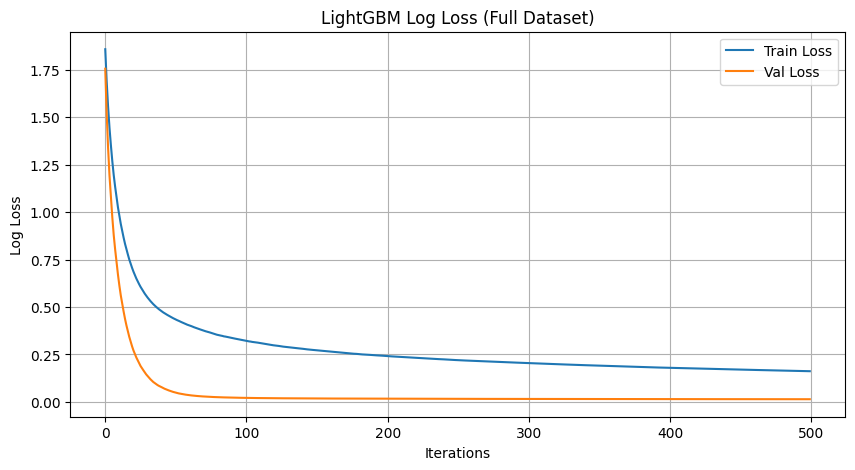

In [25]:
# 6. Accuracy/Loss Curve
results = best_lgbm.evals_result_
epochs = len(results['training']['multi_logloss'])
x_axis = range(0, epochs)



plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['training']['multi_logloss'], label='Train Loss')
plt.plot(x_axis, results['valid_1']['multi_logloss'], label='Val Loss')
plt.title('LightGBM Log Loss (Full Dataset)')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.grid()
plt.legend()
plt.show()
